# HEART RATE ESTIMATION

The goal of this assignment is to estimate the heart rate of a healthy subject, given linear acceleration and angular velocity measurements recorded by using a MuSe platform. The study must be performed on two datasets: the first is the compulsory one (**center_sternum.txt**) while the second is left at the discretion of the group, among those made available for the assignment.

**N.B: Remember that normal beat is around [40-100] bpm.**

The data is provided in .txt file. During this study two healthy subjects were involved with their informed consent. The first dataset was recorded on one subject, while all the other datasets were recorded on the second subject. 

This is the first mandatory file:

* **center_sternum.txt**: MuSe placed on the center of the sternum. The subject was lying supine on his left and right side, respectively. 


Choose one of the following files in order to complete the task.

1. **1_Stave_supine_static.txt**: Sensor placed on a bed stave, under the mattress at the level of the chest. The subject was lying supine on his left and right side. 
* **2_Mattress_supine.txt**: Sensor placed on the mattress, near one corner but not under the pillow. The subject laid in the same position as above. 
* **3_Subject_sitting_chair.txt**: Sensor placed on the desk: the subject, sitting on a chair, leaned forearms and hands on the desk. 
* **4_Chest_sweater.txt**: Sensor placed on the subject chest directly on a sweater. 
* **5_Under_chair.txt**: Subject sitting on a chair, sensor placed under the seat of the chair. 

All .txt files give 16 columns index, in particular: 

* Log Freq stands for the acquisition  in Hz (i.e., sampling interval is constant).
* AccX, AccY, AccZ are the measured magnitude of linear acceleration along each axis.
* GyroX, GyroY, GyroZ are the measured magnitude of angular velocity along each axis.
* MagnX, MagnY, MagnZ are the measured magnitude of magnetic field along each axis.
* qw, qi, qj, qk are the quaternion components, representing the spatial orientation of the Muse system.

Each dataset includes, in addition to the data, one file containing the adopted configuration of the MuSe(**README1.txt** for the first measurement, and in **README_5.txt** for the other measurement).
 


## Assignment



1. Data preparation:

    1.1. Load the txt file and select only the columns you are interesting in, in order to do a complete data analysis (e.g. Log Freq, AccX, ... )
    
    1.2. Plot selected data in function of time and choose a properly time window over which to perform the analysis. Pay attention on time rappresentation and the measurament unit.
    
    1.3. In order to make an appropiate work, decide if take care about some particular axis or some combination of them as well as derived features for the next step of the task. Motivate your choice.  


    
2. Time and frequency analysis:

    2.1. Statistical analysis: provide a statistical description of the chosen dataset. Statistical descriptors includes for example mean, median, variance, standard deviation, 25th and 75th percentiles, and correlation coefficients. Investigate what could be the most interesting descriptors for this type of data, motivating the choices.
    
    2.2. Fourier Analysis: Perform a frequency analysis of the data. Look at the spectrum and explain what you see. Use this step in order to properly design the filters in the following step. 



3. Filter:
    
    Implement your own filter, trying to extrapolate heart rate signal. Hint:
    
    (a) Directly from Fourier Analysis, antitrasform data looking for the most interesting frequency band.
    
    (b) Choose the appropriate Lowpass/Bandpass/Highpass filter.
    
    (c) Wavelet trasform (a powerfull instrument that make a time and frequency analysis of signal).
    
    (d) Find another method by yourselves.
    
    Motivate your choice.
    
    
4. Metrics:

    4.1. Heart Beat Per Minute(BPM): extrapolate BPM, make an histogram of the result. Does it follow a partiular distribution? 
    
    4.2. Heart Rate Variability(HRV): extrapolate HRV, explain why this parameter is important, and plot the results.


5. Conclusion: 

    Summarise the obtained results, in particular making a comparison between the two files analysed. Highlight limitation and critical issues encountered during the work, motivating the most relevant contribution given by your solution.

# Project execution

## Introduction

The human body constantly emits life signs that can be detected with inertial sensors, such as accelerometers, gyroscopes, and magnetometers **(Haescher, 2015)**. In practice, these sensors are integrated through a device called an Inertial Measurement Unit (IMU) that allows, for example, tracing the heart activity thanks to small body movements caused by the contraction and relaxation of the heart. 

This way to monitor the heart is known as ballistocardiography (BCG) or seismocardiography (SCG). In simple terms, BCG and SCG are both  non-invasive techniques used to monitor the human heart, based on its mechanical activity. These techniques record the micromovements induced by cardiovascular activity at the body’s center of mass and on the chest **(Balali, 2022)**.

<center>
  <img src="example.png" width="40%">
</center>

### Which signals to keep?

The majority of wearable systems for detecting muscle activity are based on accelerometry because accelerometers provide a direct measurement of linear acceleration associated with body movements **(Haescher, 2015)**. In addition, angular rate measurements recorded by a gyroscope are  commonly used since they complement the accelerometer by providing information about rotational motion. 

Other measurements, such as the magnetic field, are often used to detect the direction of the magnetic north for geographic positioning, or simply detect a magnetic field near the device, but also to reduce drift in gyroscope-based measurements. Unfortunately, magnetometers are difficult to manage because of magnetic perturbations **(Belaish & Zigliotto, 2022)**. 

For this reason, we retain only the accelerometer (Acc) and gyroscope (Gyro) signals in our analysis. This simplification aligns with common wearable configurations, but moreover allows us to capture the most relevant motion-related information while reducing data dimensionality and potential noise that could be introduced by increasing the data.

### Which datasets to choose?

In this study, two datasets were selected to estimate heart rate using different sensing approaches. The mandatory dataset, *center_sternum.txt*, corresponds to SCG technique, where the sensor is placed directly on the sternum to measure local chest vibrations generated by cardiac mechanical activity. 

As the second dataset, *1_Stave_supine_static.txt* was chosen because it represents BCG technique, where the sensor is positioned under the mattress and detects subtle whole-body movements caused by cardiac contractions and blood ejection through the vascular system. 

These two datasets were selected in order to compare heart rate estimation results obtained from two different physiological measurement principles: local chest vibration sensing (SCG) and whole-body motion sensing (BCG).

The dataset *4_Chest_sweater.txt* was not selected because it also corresponds to seismocardiography and would therefore not provide a methodological comparison. The remaining datasets correspond to BCG configurations, but the bed-stave configuration was chosen since bed-based BCG systems are among the most widely studied approaches for unobtrusive heart-rate monitoring in the literature **(Inan, 2014)**

**Although the motivation for retaining only accelerometer and gyroscope signals is primarily based on theoretical considerations from the consulted literature (in the same way that the selection of the two datasets was done), we also performed an exploratory analysis of all available data in the assignment.**

## Libraries

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import fft
from scipy import linalg as la
import seaborn as sns
from scipy import signal




In [11]:
# Defining color palettes for plots

acc_colors = ['orange', 'deeppink', 'purple']
gyro_colors = ["darkviolet", "darkblue", "darkcyan"]

## Dictionary of variables for reference

cs: Main dataset. MuSe placed on the center of the sternum.

ss: Secondary dataset. Sensor placed on a bed stave, under the mattress at the level of the chest. 

ms: Secondary dataset. Sensor placed on the mattress, near one corner but not under the pillow.

sc: Secondary dataset. Sensor placed on the desk: the subject, sitting on a chair, leaned forearms and hands on the desk. 

ch: Secondary dataset. Sensor placed on the subject's chest directly on a sweater. 

uc: Secondary dataset.  Subject sitting on a chair, sensor placed under the seat of the chair. 

## Data selection and exploratory analysys

In [12]:
#calibration of the second person datasets
gyro_cali = np.array([-2.804399,	1.793105,	0.3411708])

acc_cali = np.array([[1.002982,9.415505E-05,0.004346743],
[9.04459E-05,1.002731,-0.001444198],
[0.004346536,-0.001444751,1.030587]])

acc_offset = np.array([3.602701,-20.96658, 54.97186])

In [13]:
file_names = [
    "1_Stave_supine_static.txt",
    "2_Mattress_supine.txt",
    "3_Subject_sitting_chair.txt",
    "4_Chest_sweater.txt",
    "5_Under_chair.txt"
]

datasets = {}

for i, file in enumerate(file_names, start=1):
    datasets[i] = pd.read_csv(file, sep='\t')

In [14]:
for i in range(1,6):
    acc_raw = datasets[i][['AccX','AccY','AccZ']].values
    acc_corrected = (acc_raw - acc_offset[0])@acc_cali.T
    datasets[i][['AccX','AccY','AccZ']] = acc_corrected

    gyro_raw = datasets[i][['GyroX','GyroY','GyroZ']].values
    gyro_corrected = gyro_raw - gyro_cali
    datasets[i][['GyroX','GyroY','GyroZ']] = gyro_corrected
datasets[2].head()

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,100,1555487805,414.971439,-259.881154,844.113775,74.023909,-15.085785,18.805169,-251,144,-456,0.056576,-0.154179,0.248573,-0.954588
1,5,100,1555487805,385.154549,-152.688372,1039.464488,27.682449,0.402017,11.366149,-618,152,-247,0.094745,-0.193243,0.047029,-0.975433
2,5,100,1555487805,364.719091,-134.013256,1024.261523,42.804399,-4.841885,20.756389,-618,152,-248,0.057454,-0.193945,0.045503,-0.978271
3,5,100,1555487805,393.423522,-140.375893,939.905161,39.633669,1.987383,25.268589,-618,152,-247,0.046736,-0.193915,0.044099,-0.978912
4,5,100,1555487805,406.168963,-155.999729,915.968664,36.097079,9.914215,30.024679,-617,151,-248,0.042185,-0.193335,0.043092,-0.979278


# DataSet 1 - EDA

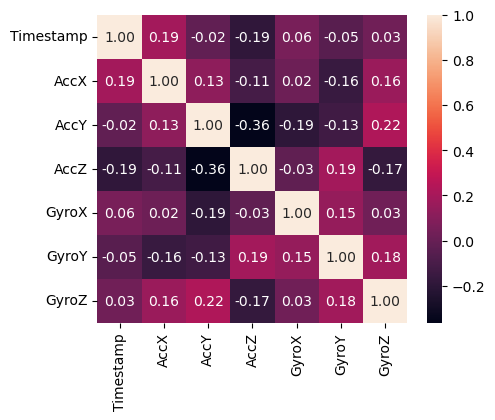

In [15]:
cols = ['Timestamp','AccX','AccY',	'AccZ',	'GyroX',	'GyroY',	'GyroZ']
        #,	'MagnX',	'MagnY',	'MagnZ',	'qw',	'qi',	'qj',	'qk']
corr_matrix = datasets[1][cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

In [16]:
for i, file in enumerate(file_names, start=1):
    datasets[i]['MagAcc']=np.sqrt(datasets[i]['AccX']**2 + datasets[i]['AccY']**2 + datasets[i]['AccZ']**2)
    datasets[i]['MagGyro']=np.sqrt(datasets[i]['GyroX']**2+datasets[i]['GyroY']**2+datasets[i]['GyroZ']**2)

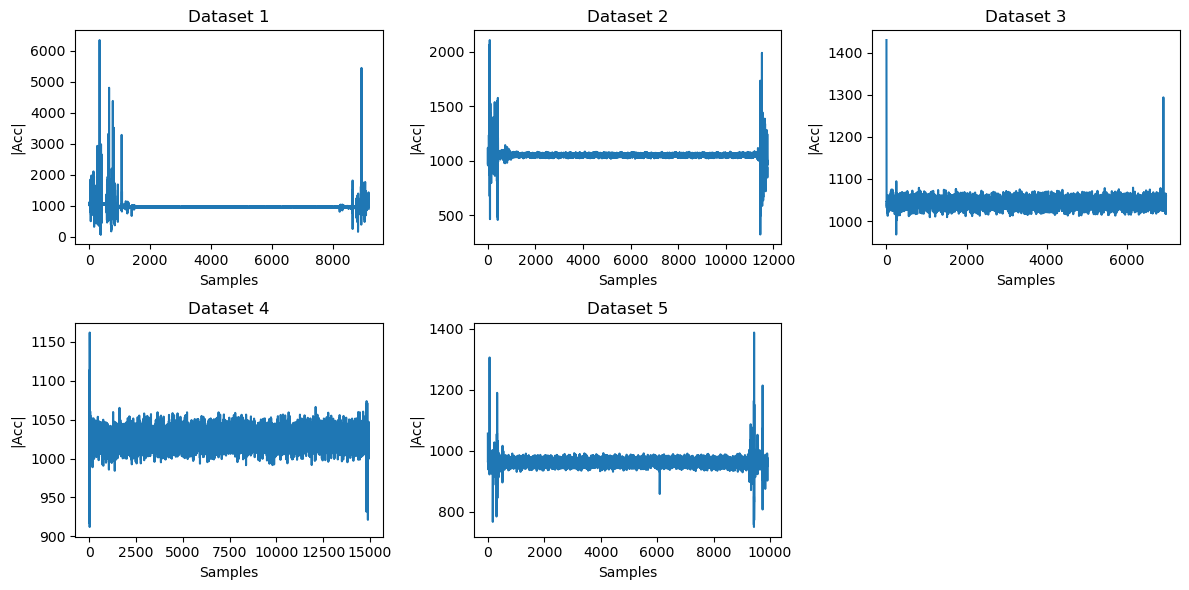

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i in range(1, 6):
    
    df = datasets[i]
    time = np.arange(len(df))
    
    axes[i-1].plot(time, df['MagAcc'])
    axes[i-1].set_title(f'Dataset {i}')
    axes[i-1].set_xlabel('Samples')
    axes[i-1].set_ylabel('|Acc|')

# remover o sexto subplot (o vazio)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()



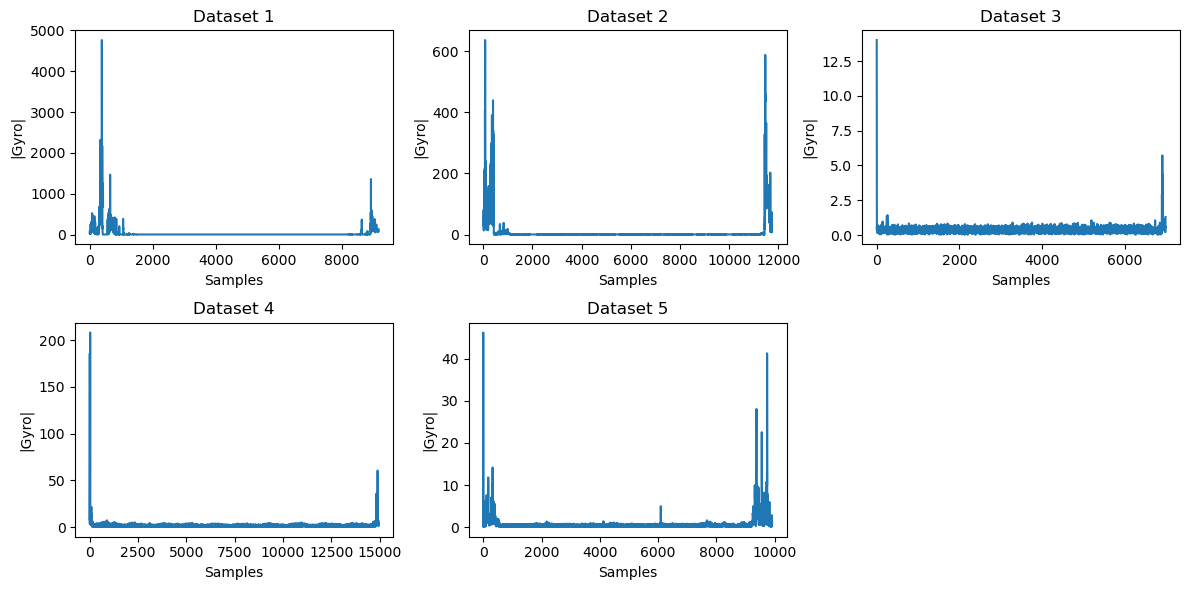

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i in range(1, 6):
    
    df = datasets[i]
    time = np.arange(len(df))
    
    axes[i-1].plot(time, df['MagGyro'])
    axes[i-1].set_title(f'Dataset {i}')
    axes[i-1].set_xlabel('Samples')
    axes[i-1].set_ylabel('|Gyro|')

# remover o sexto subplot (o vazio)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Data preparation

In [19]:
# Loading all the files

cs=pd.read_csv('center_sternum.txt',sep='\t')
#cs.info()

ss=pd.read_csv('1_Stave_supine_static.txt', sep='\t')
#ss.info()

ms=pd.read_csv('2_Mattress_supine.txt',sep='\t')
#ms.info()

sc=pd.read_csv('3_Subject_sitting_chair.txt',sep='\t')
#sc.info()

ch=pd.read_csv('4_Chest_sweater.txt',sep='\t')
#ch.info()

uc=pd.read_csv('5_Under_chair.txt',sep='\t')
#uc.info()

In [20]:
# Selection of the columns we are interested in

cs = cs[['Timestamp', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY',	'GyroZ']].copy()

In [21]:
# Calibration

A = np.array([
    [1.000966,    -0.002326418, -0.0006995499],
    [-0.002326379, 0.9787045,   -0.001540918],
    [-0.0006995811, -0.001540928, 1.00403]
])

acc_offset = np.array([-3.929942, -13.74679, 60.67546])
gyro_offset = np.array([-2.242224, 2.963463, -0.718397])

acc_raw_data = cs[['AccX', 'AccY', 'AccZ']].values
gyro_raw_data = cs[['GyroX', 'GyroY', 'GyroZ']].values

acc_calibrated_data = (acc_raw_data - acc_offset) @ A.T
gyro_calibrated_data = (gyro_raw_data - gyro_offset)

cs[['AccX_cal', 'AccY_cal', 'AccZ_cal']] = acc_calibrated_data 
cs[['GyroX_cal', 'GyroY_cal', 'GyroZ_cal']] = gyro_calibrated_data

In [22]:
# Plot selected data in function of time to choose a properly time window over which to perform the analysis.
# I GUESS THIS HAS ALREADY BEEN PRESENTED IN THE EXPLORATORY SECTION, but I put it here because I cannot access the file on git

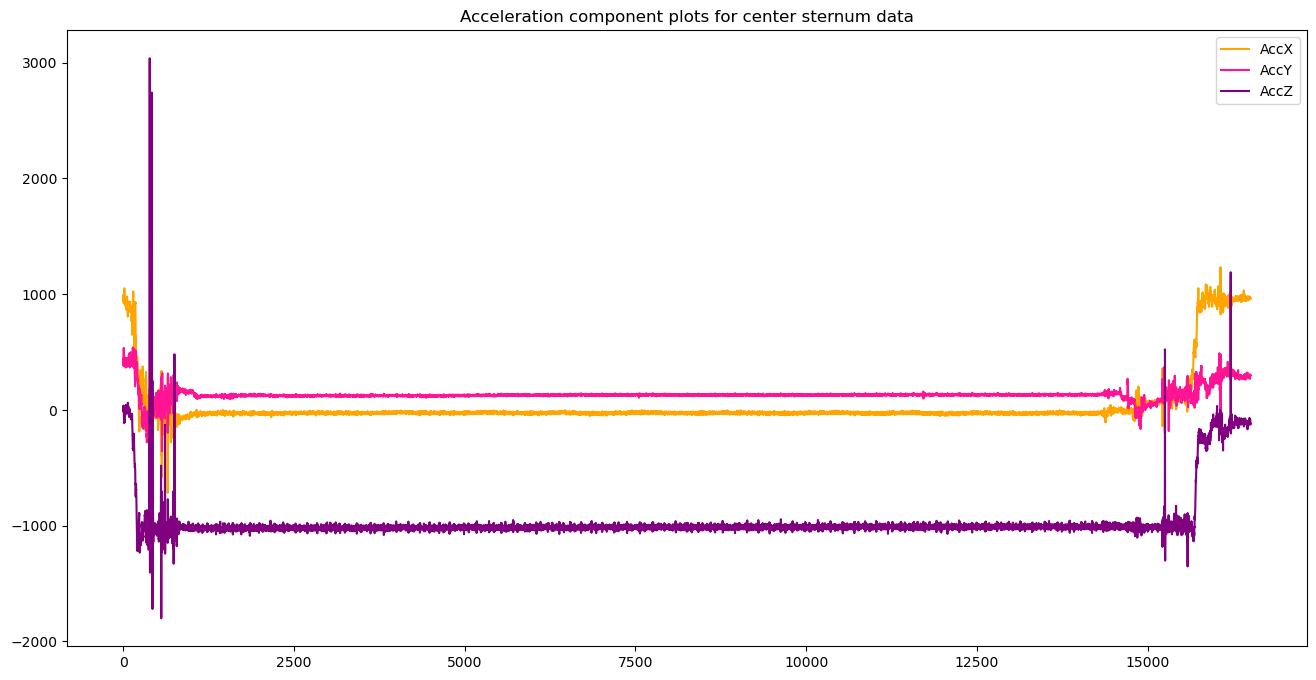

In [23]:
plt.figure(figsize=(16, 8))
plt.plot(cs['AccX_cal'], label='AccX', color=acc_colors[0])
plt.plot(cs['AccY_cal'], label='AccY', color=acc_colors[1])
plt.plot(cs['AccZ_cal'],label='AccZ', color=acc_colors[2])
plt.title('Acceleration component plots for center sternum data')
plt.legend()

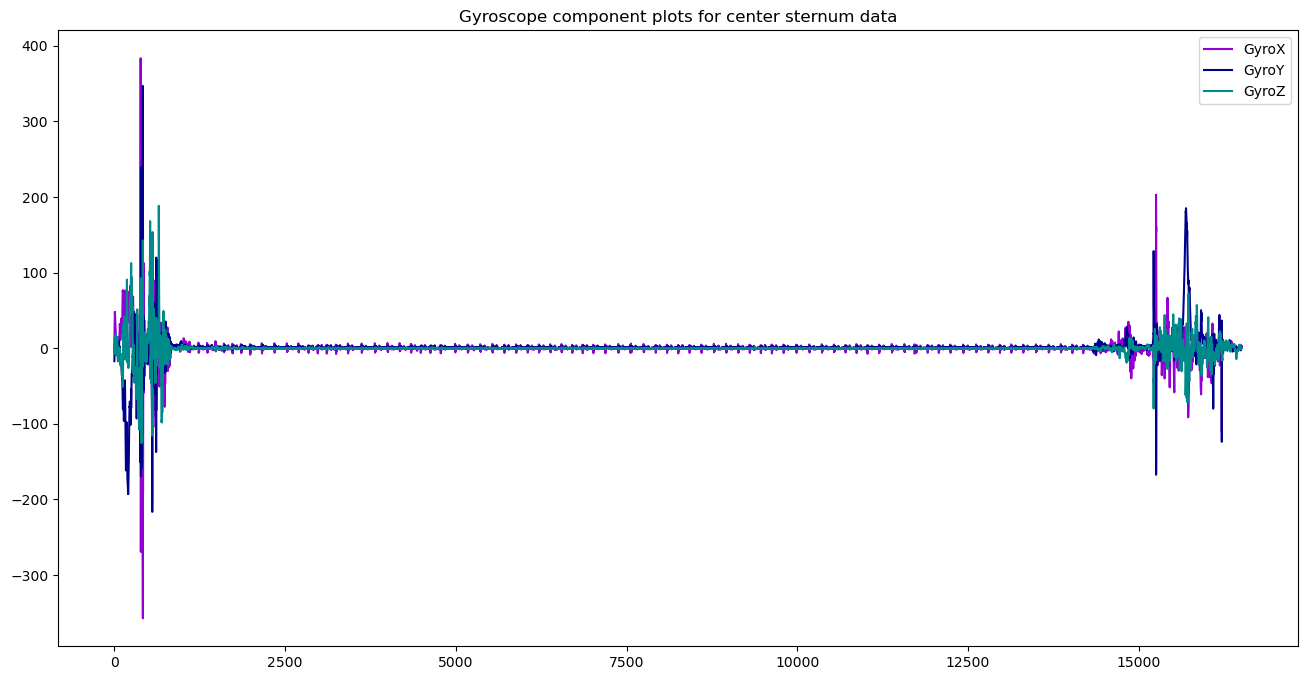

In [24]:
plt.figure(figsize=(16, 8))
plt.plot(cs['GyroX_cal'], label='GyroX', color=gyro_colors[0])
plt.plot(cs['GyroY_cal'], label='GyroY', color=gyro_colors[1])
plt.plot(cs['GyroZ_cal'], label='GyroZ', color=gyro_colors[2])
plt.title('Gyroscope component plots for center sternum data')
plt.legend()

The initial and terminal spikes in the previous plots likely represent motion from when the sensor was first attached and finally removed.

To select an appropriate time window for the analysis, we examine zoomed-in views of each component. This allows us to determine which rows should be discarded.

In the following plots, the first row displays the first N rows of each acceleration/gyroscope component, corresponding to the initial portion of the signal, while the second row shows the last N rows of each component, corresponding to the final portion of the recording. The columns, from left to right, correspond to the X-component, Y-component and Z-component, respectively.

In [25]:
N=3000 # number of rows for the zoom-in views

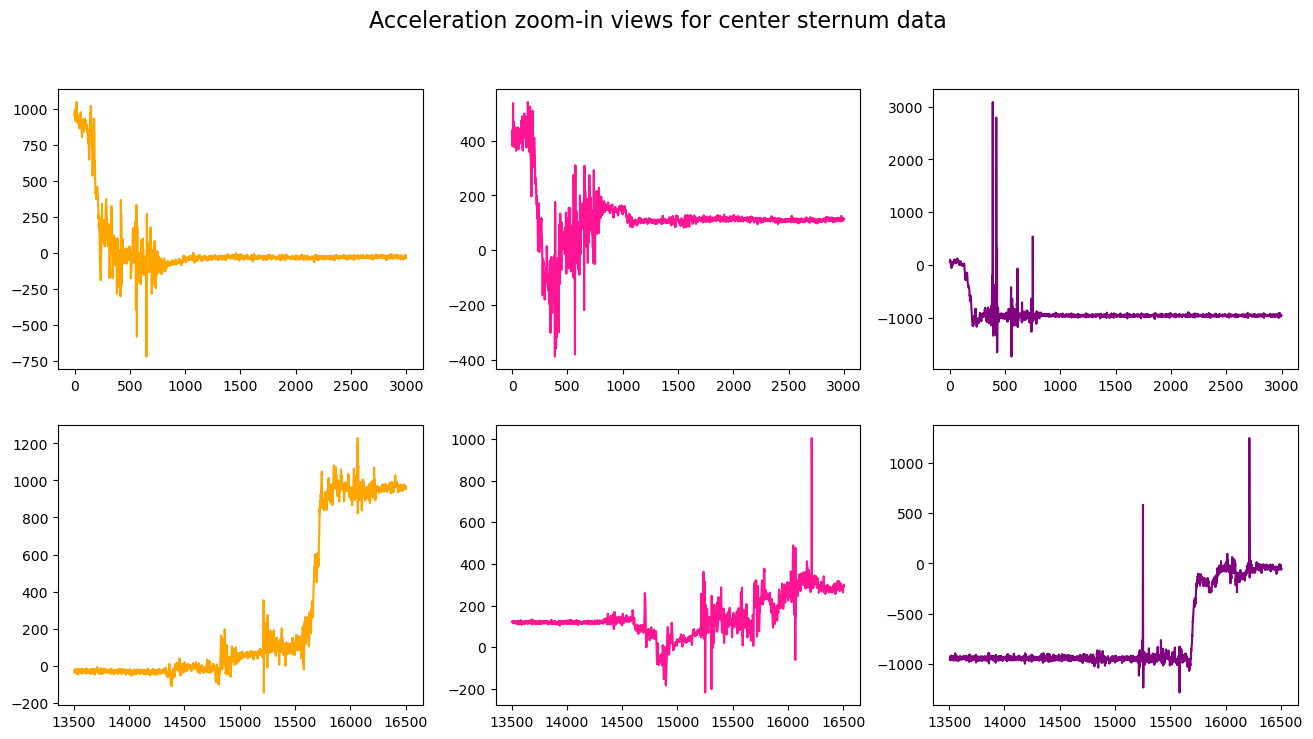

In [26]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Acceleration zoom-in views for center sternum data', fontsize=16)
ax1.plot(cs["AccX"][:N],color=acc_colors[0])
ax2.plot(cs["AccY"][:N],color=acc_colors[1])
ax3.plot(cs["AccZ"][:N],color=acc_colors[2])

ax4.plot(cs["AccX"][-N:],color=acc_colors[0])
ax5.plot(cs["AccY"][-N:],color=acc_colors[1])
ax6.plot(cs["AccZ"][-N:],color=acc_colors[2])

plt.show()

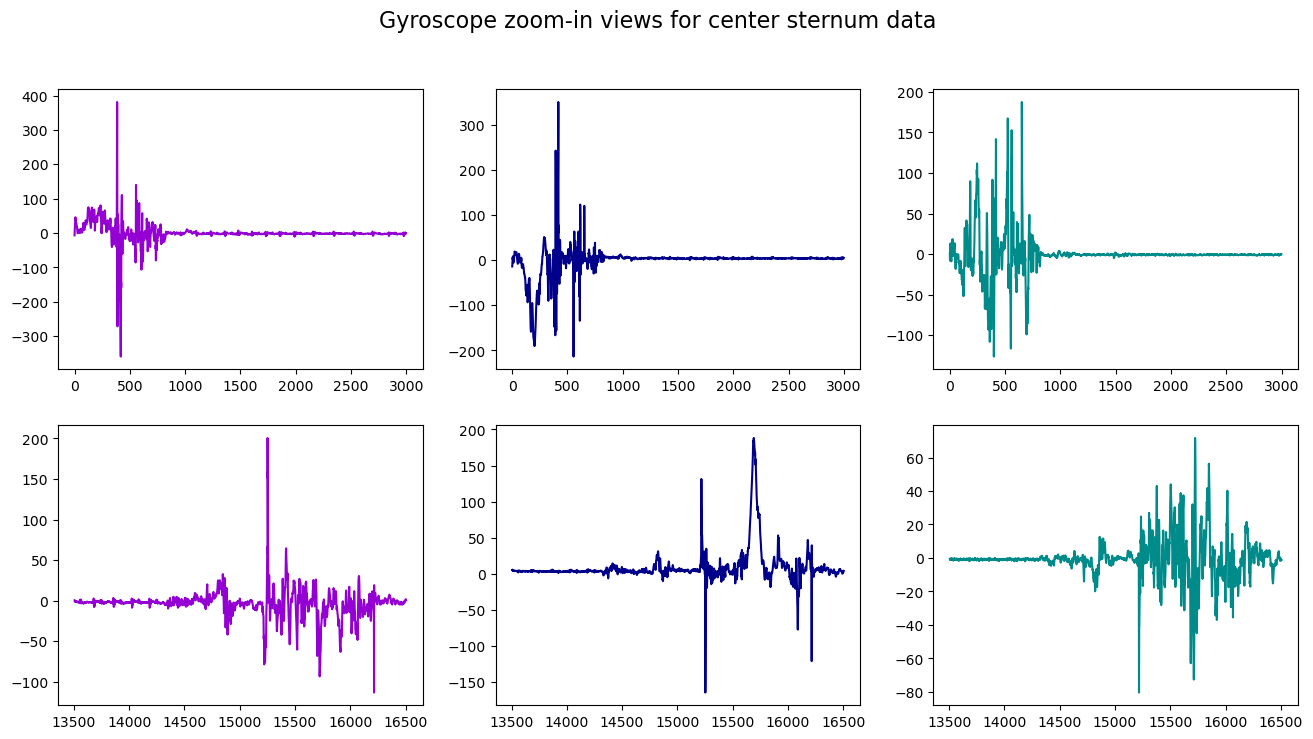

In [27]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Gyroscope zoom-in views for center sternum data', fontsize=16)
ax1.plot(cs["GyroX"][:N],color=gyro_colors[0])
ax2.plot(cs["GyroY"][:N],color=gyro_colors[1])
ax3.plot(cs["GyroZ"][:N],color=gyro_colors[2])

ax4.plot(cs["GyroX"][-N:],color=gyro_colors[0])
ax5.plot(cs["GyroY"][-N:],color=gyro_colors[1])
ax6.plot(cs["GyroZ"][-N:],color=gyro_colors[2])

plt.show()

**Based on this graphs, the data will be analyzed from 1000:-2500 in the center sternum dataset and x:x in B**

In [101]:
# Select row range for analysis
cs_clean = cs[1000:-3000].copy()

# Drop raw columns keeping only calibrated data
raw_columns = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
cs_clean.drop(columns=raw_columns, inplace=True)

Finally, over the clean dataset we compute the magnitude of the acceleration and the time in seconds, adding two new columns to the data.

Following Haescher(2015), a combined signal from the three axes was generated by computing the magnitude of the acceleration vector: $$a= \sqrt{a_x^2 + a_y^2 +az^2}$$

Then, the mean of the magnitud is substracted because this is according to the literature, the value of the gravity, which drives to a shif over the y axis of the values.

In [112]:
cs_clean['MagAcc']=np.sqrt(cs_clean['AccX_cal']**2 + cs_clean['AccY_cal']**2 + cs_clean['AccZ_cal']**2)
cs_clean['MagAcc']=cs_clean['MagAcc']-cs_clean['MagAcc'].mean() 
cs_clean['GyrAcc']=np.sqrt(cs_clean['GyroX_cal']**2 + cs_clean['GyroY_cal']**2 + cs_clean['GyroZ_cal']**2)
cs_clean['GyrAcc']=cs_clean['GyrAcc']-cs_clean['GyrAcc'].mean() 

To obtain a proper time representation, we use Python’s built-in datetime module, which provides classes for manipulating dates and times. Specifically, we use the fromtimestamp() function of the datetime.date class.

The fromtimestamp() function returns the date corresponding to a given Unix timestamp (this is a way to track time as a running total of seconds. The count starts on January 1st, 1970 at UTC). To make sure that the timestamps from the data are indeed given in Unix timestamp format we perform the following check.

In [113]:
# We took the first and final timestamp from the dataset and printed the date to check if it's the same as in the README file.
# This also allows us to know the number of seconds that the measurement lasted.

first_stamp = 1576222772
last_stamp = 1576222847
first_date = datetime.datetime.fromtimestamp(first_stamp)
last_date = datetime.datetime.fromtimestamp(last_stamp)

print(first_date) 
print(last_date)
# for the first subject, it lasted 75 seconds

2019-12-13 02:39:32
2019-12-13 02:40:47


In [114]:
# From the README file we know the frequency must be 200 Hz (meaning 200 records per second).
# We verify using value_counts() for each timestamp.

freq_cs = cs['Timestamp'].value_counts()
freq_cs

Timestamp
1576222772    224
1576222774    224
1576222778    224
1576222776    224
1576222783    224
             ... 
1576222834    210
1576222841    210
1576222844    210
1576222846    210
1576222847    182
Name: count, Length: 76, dtype: int64

In [115]:
# mean frequency calculation
meanfreq_cs = freq_cs = cs['Timestamp'].value_counts().mean()
meanfreq_cs

np.float64(217.18421052631578)

In [116]:
# time column using mean frequency

cs_clean['Time'] = np.arange(len(cs_clean))/meanfreq_cs
cs_clean
# makes sense because our previous calculation indicated the measurement lasted 75 seconds and we already drop some rows.

,Timestamp,AccX_cal,AccY_cal,AccZ_cal,GyroX_cal,GyroY_cal,GyroZ_cal,MagAcc,GyrAcc,Time
1000,1576222776,-40.098619,149.496490,-1017.661849,2.913980,1.387682,1.283282,6.154603,1.953292,0.000000
1001,1576222776,-41.489264,144.128734,-1018.999816,3.127720,1.143407,0.810000,6.767583,1.907261,0.004604
1002,1576222776,-40.763430,146.152352,-1016.063724,3.692606,1.051804,0.168779,4.119746,2.323192,0.009209
1003,1576222776,-44.917316,145.797780,-1012.140525,3.845277,1.097606,0.122977,0.363033,2.480753,0.013813
1004,1576222776,-62.408146,151.237974,-990.517096,3.830010,0.685392,-0.014427,-19.272454,2.370881,0.018418
...,...,...,...,...,...,...,...,...,...,...
13501,1576222834,-26.682465,133.719300,-1027.384467,-4.215791,0.089972,-0.747252,13.182969,2.762450,57.559433
13502,1576222834,-33.150020,122.882220,-997.229982,-3.956249,0.654858,-0.441908,-17.891456,2.514357,57.564037
13503,1576222834,-34.342838,133.735360,-987.385699,-2.566936,2.288445,0.000840,-26.217582,1.918916,57.568642
13504,1576222834,-30.690893,134.001381,-971.771043,-0.597471,3.097606,0.184046,-41.764094,1.640065,57.573246


In [117]:
cs_clean['MagAcc'].mean()

np.float64(1.3788597109879033e-13)

In this way, we finally have the interval object of the subsequent analysis

Text(0.5, 1.0, 'Magnitude of Gyroscope')

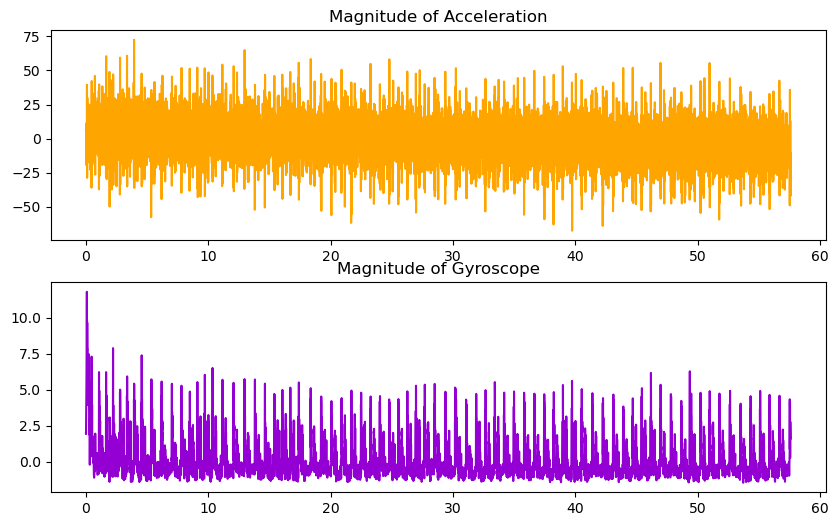

In [118]:
figure, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(cs_clean['Time'], cs_clean['MagAcc'], color=acc_colors[0])
ax[0].set_title("Magnitude of Acceleration")

ax[1].plot(cs_clean['Time'], cs_clean['GyrAcc'], color=gyro_colors[0])
ax[1].set_title("Magnitude of Gyroscope")

### PCA

In order to choose the components of accelerometer and gyroscope to work with, we performed a PCA analysis on each.

In [119]:
# PCA for accelerometer

pca_acc = cs[["AccX_cal", "AccY_cal", "AccZ_cal"]]

cov_matrix_acc = pca_acc.cov()
l, v = la.eig(cov_matrix_acc)

percent_variability = l.real * 100 / np.sum(l.real)
indexes = np.argsort(-percent_variability)

for i in percent_variability[indexes]:
    if i > 0.0:
        print(f'{i:.3f}%')
    else:
        print(f'{i:.3e}%')

94.294%
3.904%
1.801%


In [120]:
# PCA for gyroscope

pcc_gyr = cs[["GyroX_cal", "GyroY_cal", "GyroZ_cal"]]

cov_matrix_gyr = pcc_gyr.cov()
l, v = la.eig(cov_matrix_gyr)

percent_variability = l.real * 100 / np.sum(l.real)
indexes = np.argsort(-percent_variability)

for i in percent_variability[indexes]:
    if i > 0.0:
        print(f'{i:.3f}%')
    else:
        print(f'{i:.3e}%')

60.337%
20.758%
18.905%



Performing the same procedure on each dataset, we obtained the following percentages of variance.

| Dataset | Ax  | Ay  | Az  | Gx  | Gy  | Gz  |
|------|-----|-----|-----|-----|-----|-----|
| cs | 94.2 | 3.80 | 1.80 | 60.3 | 20.8 | 18.9 |
| ss | 80.8 | 10.4 | 8.80 | 49.7 | 34.8 | 15.5 |
| ms | 50.7 | 34.2 | 15.1 | 48.6 | 32.0 | 19.3 |
| sc | 53.4 | 33.9 | 12.0 | 42.7 | 39.8 | 17.5 |
| ch | 75.3 | 15.6 | 9.00 | 82.1 | 18.4 | 0.40 |
| uc | 73.4 | 18.2 | 8.30 | 49.9 | 34.9 | 15.1 |

**Based on the PCA we decided to...**

## Statistical analysis

The **mean** describes the average value of the signal and is useful to understand the general orientation of the sensor relative to gravity. For example, a large constant value in one accelerometer axis usually corresponds to the gravitational component, which indicates the orientation of the sensor on the body.

The **standard deviation** measures the variability of the signal around the mean and is particularly important for SCG/BCG signals because it reflects the amplitude of small vibrations caused by cardiac activity and respiration. 

**Median (50th percentile)** represents the middle of the data distribution, meaning that 50% of the values lie below it and 50% above it. 

**Minimum** and **maximum** also may be important because **minimum** indicates the smallest value of the signal, **maximum** - largest one. These descriptors help to understand the full range of the signal.

In [121]:
cs_stats_table = (
    cs_clean[['AccX_cal','AccY_cal','AccZ_cal','GyroX_cal','GyroY_cal','GyroZ_cal']]
    .describe()
    .loc[['mean','std','50%', 'min', 'max']]
    .round(2)
)

In [122]:
cs_stats_table

,AccX_cal,AccY_cal,AccZ_cal,GyroX_cal,GyroY_cal,GyroZ_cal
mean,-26.63,127.63,-1014.82,0.20,0.74,-0.14
std,7.29,5.94,14.68,1.56,0.76,0.43
50%,-26.52,127.94,-1015.19,0.10,0.69,-0.14
min,-65.04,95.55,-1087.59,-8.64,-4.69,-4.23
max,1.82,173.04,-944.40,13.14,4.78,2.84


## Fourier analysis

Peak frequency: 1.25 Hz
Heart rate: 75.02 bpm
Peak frequency: 1.25 Hz
Heart rate: 75.02 bpm
Peak frequency: 1.25 Hz
Heart rate: 75.02 bpm


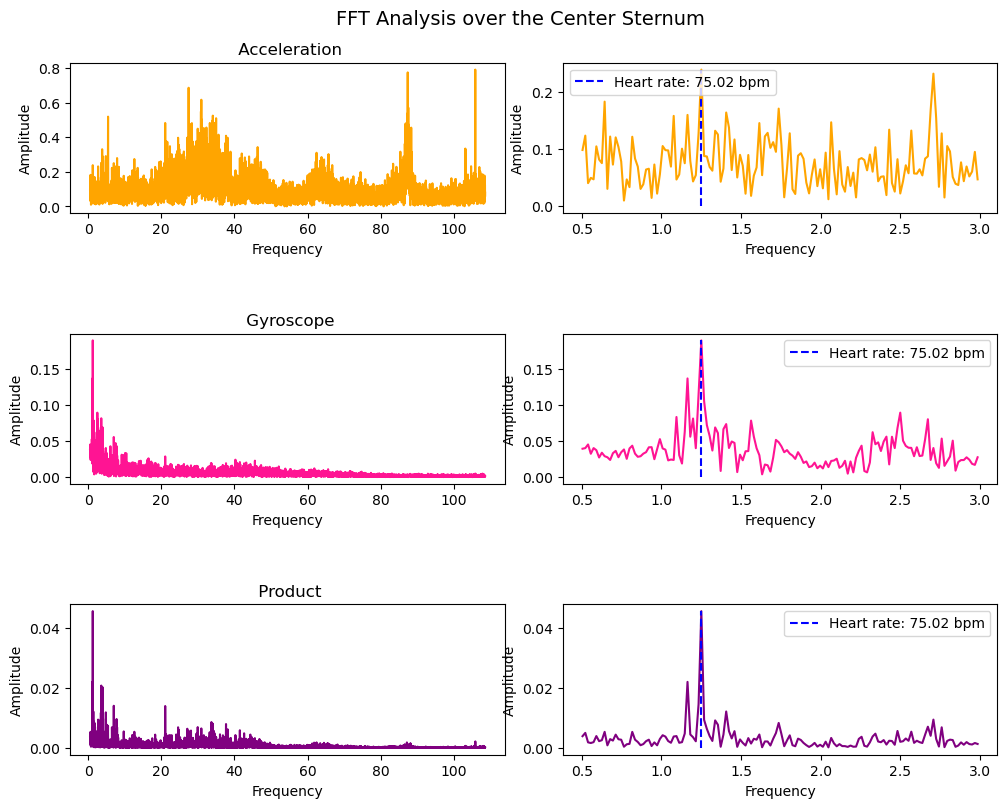

In [146]:
dt = 1/meanfreq_cs

# no se hizo restar mean
cs_fft = fft.fft(cs_clean['MagAcc'].values, axis=0, norm="forward")
freqs = fft.fftfreq(np.array(cs_clean['MagAcc']).size, d=dt)

cs_fft_gyro = fft.fft(cs_clean['GyrAcc'].values, axis=0, norm="forward")
freqs_gyro = fft.fftfreq(np.array(cs_clean['GyrAcc']).size, d=dt)

#mask1 = (freqs > 0.6) & (freqs < 1.6) # teniendo en cuenta que el rango normal es de 40 a 100 bpm
mask = freqs > 0.5
mask1 = (freqs > 0.5) & (freqs < 3.0) # For bpm range of 40 to 120
f_plot = freqs[mask]
p_plot_a = np.abs(cs_fft[mask])
p_plot_g = np.abs(cs_fft_gyro[mask])

# Finding the peaks and the associated bpm
max_idx = [np.argmax(np.abs(cs_fft[mask1])), np.argmax(p_plot_g), np.argmax(p_plot_a*p_plot_g)]
peak_freq = [f_plot[max_idx[0]], f_plot[max_idx[1]], f_plot[max_idx[2]]]
bpm = [freq * 60 for freq in peak_freq]
for i in range(3):
        print(f"Peak frequency: {peak_freq[i]:.2f} Hz")
        print(f"Heart rate: {bpm[i]:.2f} bpm")



fig,ax = plt.subplots(3, 2, figsize=(10, 8))
ax1,ax2,ax3,ax4,ax5,ax6=ax[0,0],ax[0,1],ax[1,0],ax[1,1],ax[2,0],ax[2,1]

fig.suptitle("FFT Analysis over the Center Sternum ", fontsize=14)

ax[0,0].set_title(" Acceleration")
ax[1,0].set_title(" Gyroscope")
ax[2,0].set_title(" Product")

plt.tight_layout()
fig.subplots_adjust(hspace=0.8) 


ax1.plot(f_plot, p_plot_a, color='orange')
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Amplitude')
ax2.plot(freqs[mask1], np.abs(cs_fft[mask1]), color='orange')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Amplitude')
ax2.vlines(peak_freq[0], ymin=0, ymax=np.abs(cs_fft[mask1][max_idx[0]]), color='blue', linestyle='--',label=f"Heart rate: {bpm[0]:.2f} bpm")

ax2.legend()

ax3.plot(f_plot,p_plot_g,color='deeppink')
ax3.set_xlabel('Frequency')
ax3.set_ylabel('Amplitude')
ax4.plot(freqs[mask1], np.abs(cs_fft_gyro[mask1]), color='deeppink')
ax4.set_xlabel('Frequency')
ax4.set_ylabel('Amplitude')
ax4.vlines(peak_freq[1], ymin=0, ymax=p_plot_g[max_idx[1]], color='blue', linestyle='--',label=f"Heart rate: {bpm[1]:.2f} bpm")

ax4.legend()

ax5.plot(f_plot, p_plot_a*p_plot_g, color='purple')
ax5.set_xlabel('Frequency')
ax5.set_ylabel('Amplitude')
ax6.plot(freqs[mask1], np.abs(cs_fft[mask1])*np.abs(cs_fft_gyro[mask1]), color='purple')
ax6.set_xlabel('Frequency')
ax6.set_ylabel('Amplitude')
ax6.vlines(peak_freq[2], ymin=0, ymax=p_plot_a[max_idx[2]]*p_plot_g[max_idx[2]], color='blue', linestyle='--',label=f"Heart rate: {bpm[2]:.2f} bpm")

ax6.legend()




    


    
    


## Propose to eliminate this 4 cells

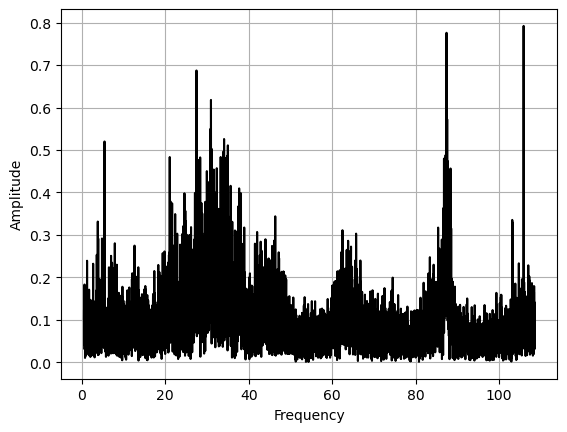

In [124]:


dt = 1/meanfreq_cs

# no se hizo restar mean
cs_fft = fft.fft(cs_clean['MagAcc'].values, axis=0, norm="forward")
freqs = fft.fftfreq(np.array(cs_clean['MagAcc']).size, d=dt)

#mask = (freqs > 0.6) & (freqs < 1.6) # teniendo en cuenta que el rango normal es de 40 a 100 bpm
mask = freqs > 0.5
f_plot = freqs[mask]
p_plot_a = np.abs(cs_fft[mask])

plt.plot(f_plot, p_plot_a, color='black')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
#plt.vlines(np.max()
plt.grid()
plt.show()

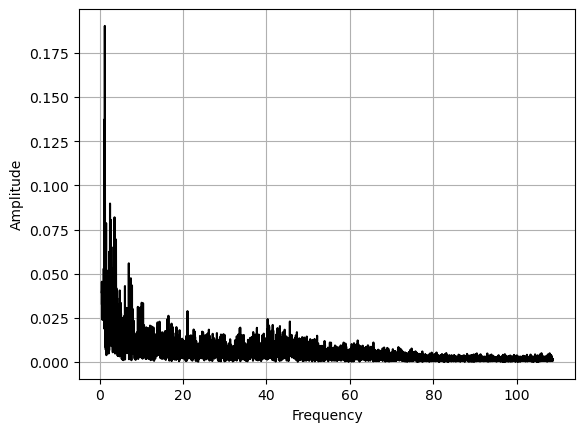

In [125]:
dt = 1/meanfreq_cs

# no se hizo restar mean
cs_fft = fft.fft(cs_clean['GyrAcc'].values, axis=0, norm="forward")
freqs = fft.fftfreq(np.array(cs_clean['GyrAcc']).size, d=dt)

#mask = (freqs > 0.5) & (freqs < 10) # teniendo en cuenta que el rango normal es de 40 a 100 bpm
mask = freqs > 0.5
f_plot = freqs[mask]
p_plot_g = np.abs(cs_fft[mask])

plt.plot(f_plot, p_plot_g, color='black')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
#plt.vlines(np.max()
plt.grid()
plt.show()

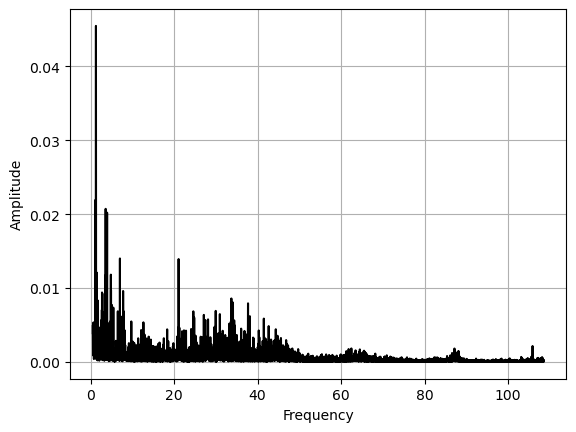

In [126]:
plt.plot(f_plot, p_plot_a*p_plot_g, color='black')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
#plt.vlines(np.max()
plt.grid()
plt.show()

In [127]:
max_idx = np.argmax(p_plot_g)       
peak_freq = f_plot[max_idx]       
bpm = peak_freq*60

print(f"Peak frequency: {peak_freq:.2f} Hz")
print(f"Heart rate: {bpm:.2f} bpm")

Peak frequency: 1.25 Hz
Heart rate: 75.02 bpm


# Continue here

### Filter implementation 

Initially the implemented filter Butterworth band-pass which takes a determinated range of frequencies and "allow" the pass over it, and outside the range it atuenates the values of the amplitudes. As we are interested in verifying the heart rate previously determinated, its important to only focus in the band between 0.6 Hz and 2.0 Hz

https://pysdr.org/es/content-es/filters.html

https://davrot.github.io/pytutorial/scipy/scipy.signal_butterworth/

C:\Users\andre\AppData\Local\Temp\ipykernel_38388\2888725105.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


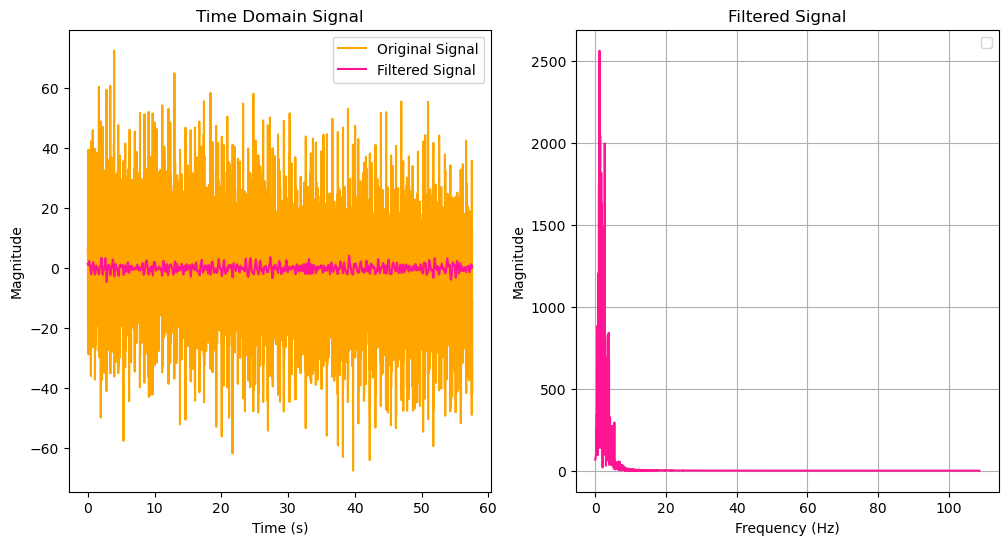

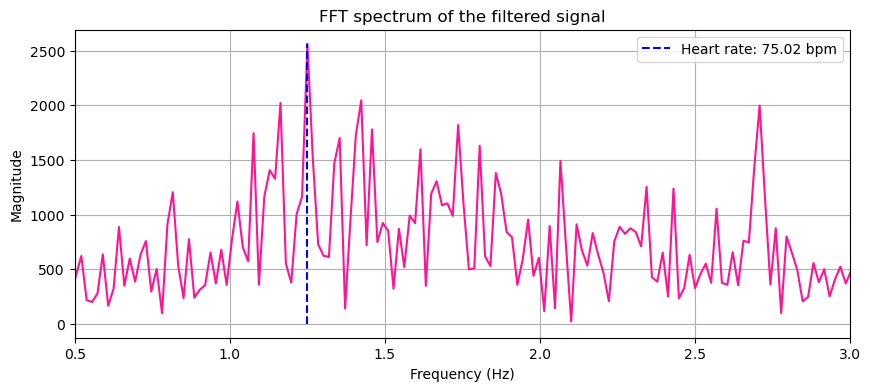

In [145]:

fs = meanfreq_cs       # frecuencia de muestreo
lowcut = 0.6          # Hz
highcut = 3.0         # Hz

# filtro Butterworth bandpass
b_band, a_band = signal.butter(
    N=2,
    Wn=(lowcut, highcut),
    btype="bandpass",
    fs=fs
)

# The input of the filter is the temporal signal, not the FFT, and then we can compare the values 
filtered_signal = signal.filtfilt(b_band, a_band, cs_clean['MagAcc'].values)


# Now performing the FFT on the filtered signal to check if the peak is more evident and if the bpm estimation is more accurate
fft_vals = np.fft.rfft(filtered_signal)
freqs = np.fft.rfftfreq(len(filtered_signal), d=1/fs)

fft_mag = np.abs(fft_vals)




fig, ax = plt.subplots(1,2,figsize=(12, 6))
ax1,ax2=ax[0],ax[1]


ax1.plot(cs_clean['Time'], cs_clean['MagAcc'], label='Original Signal', color='orange')
ax1.plot(cs_clean['Time'], filtered_signal, label='Filtered Signal', color='deeppink')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Magnitude")
ax1.set_title("Time Domain Signal")
ax1.legend()


ax2.plot(freqs, fft_mag,color='deeppink')

ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.set_title("Filtered Signal")
ax2.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(freqs, fft_mag,color='deeppink')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT spectrum of the filtered signal")
plt.xlim(0.5,3)
max_idx = np.argmax(fft_mag ) 
plt.vlines(peak_freq, ymin=0, ymax=np.abs(fft_mag[max_idx]), color='blue', linestyle='--',label=f"Heart rate: {bpm:.2f} bpm")
plt.grid()
plt.legend()
plt.show()

## To delete

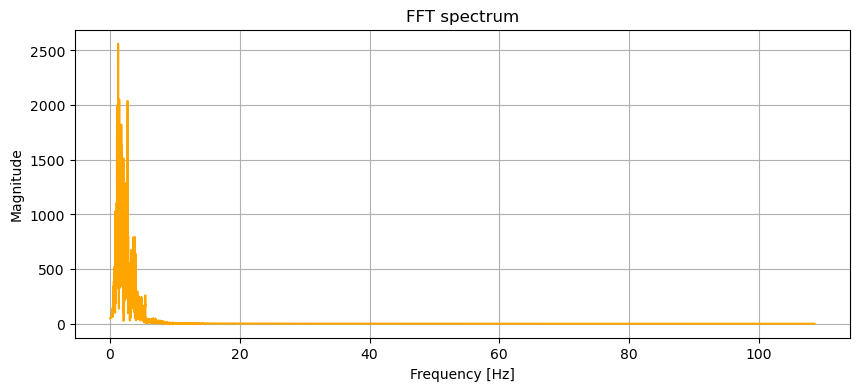

In [ ]:
fft_vals = np.fft.rfft(filtered_signal)
freqs = np.fft.rfftfreq(len(filtered_signal), d=1/fs)

fft_mag = np.abs(fft_vals)

plt.figure(figsize=(10,4))
plt.plot(freqs, fft_mag,color='orange')
#plt.xlim(0.5,2.2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT spectrum")
plt.grid()
plt.show()

## To delete

Estimated HR: 76.35 bpm


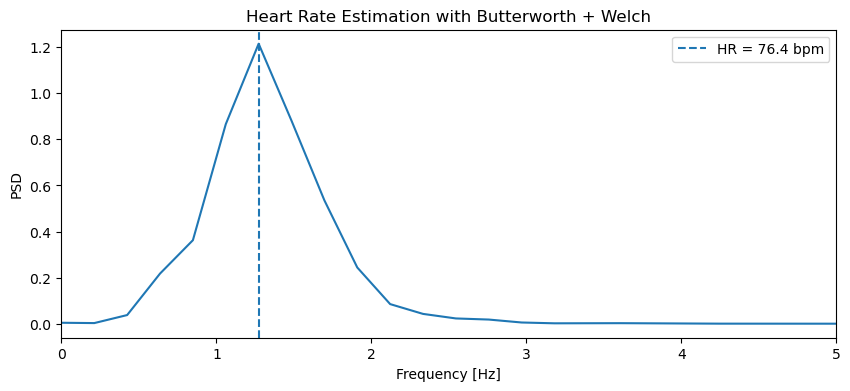

In [78]:
f_welch, pxx = signal.welch(filtered_signal, fs=fs, nperseg=1024)

# 4. Buscar HR
mask = (f_welch >= lowcut) & (f_welch <= highcut)
f_hr = f_welch[mask][np.argmax(pxx[mask])]
hr_bpm = 60 * f_hr

print(f"Estimated HR: {hr_bpm:.2f} bpm")

# 5. Graficar PSD
plt.figure(figsize=(10,4))
plt.plot(f_welch, pxx)
plt.axvline(f_hr, linestyle='--', label=f'HR = {hr_bpm:.1f} bpm')
plt.xlim(0, 5)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title("Heart Rate Estimation with Butterworth + Welch")
plt.legend()
plt.show()

Estimated HR from FFT: 75.02 bpm
Estimated HR: 78.19 bpm


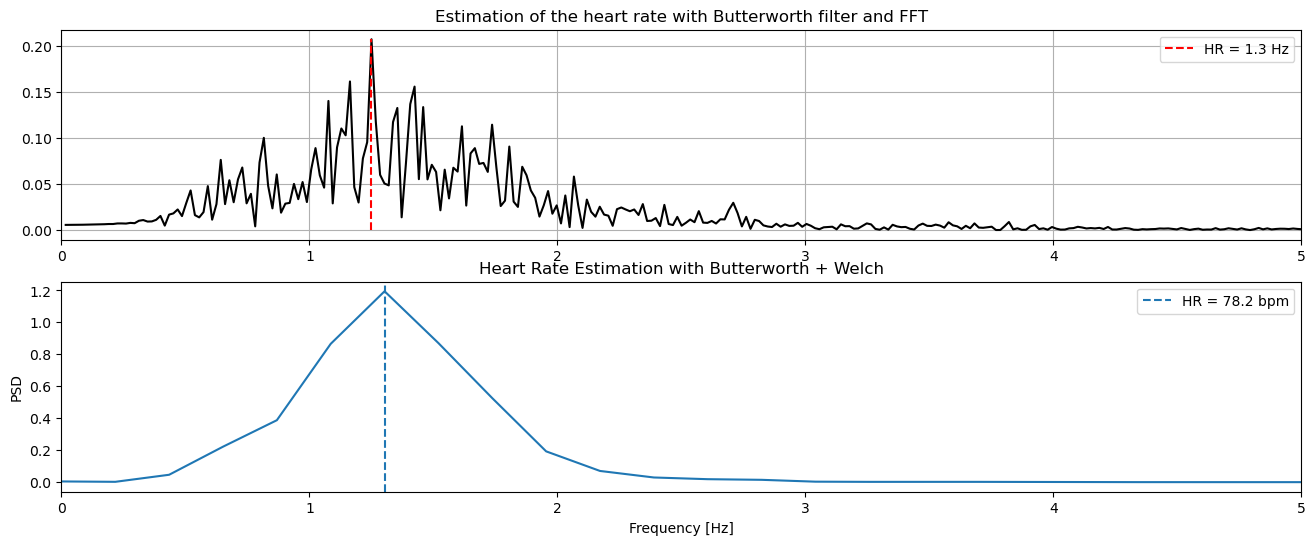

In [ ]:
import matplotlib.pyplot as plt

samples_per_second = meanfreq_cs 
cs_fft_filtered = fft.fft(filtered_signal, axis=0, norm="forward")
freqs_filtered = fft.fftfreq(len(filtered_signal), d=1/samples_per_second)
f_welch, pxx = signal.welch(filtered_signal, fs=fs, nperseg=1000)
mask= freqs_filtered > 0
f_plot= freqs_filtered[mask]
p_plot= np.abs(cs_fft_filtered[mask])
freq_bpm=f_plot[np.argmax(p_plot)]

print(f"Estimated HR from FFT: {freq_bpm*60:.2f} bpm")

mask1= (f_welch >= lowpass_frequency) & (f_welch <= highpass_frequency)
f_hr= f_welch[mask1][np.argmax(pxx[mask1])]

print(f"Estimated HR: {f_hr*60:.2f} bpm")

fig,(ax1,ax2) = plt.subplots(2, 1, figsize=(16, 6))

ax1.plot(f_plot, p_plot, color='black')
ax1.set_xlim(0,3)
ax1.vlines(freq_bpm, color='red',ymin=np.min(p_plot),ymax=np.max(p_plot), linestyle='--', label=f'HR = {freq_bpm:.1f} Hz')
ax1.grid()
ax1.legend()
ax1.set_title('Estimation of the heart rate with Butterworth filter and FFT')

ax2.plot(f_welch, pxx)
ax2.axvline(f_hr, linestyle='--', label=f'HR = {f_hr*60:.1f} bpm')
ax2.set_xlim(0, 3)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("PSD")
ax2.set_title("Heart Rate Estimation with Butterworth + Welch")
ax2.legend()

plt.show()

In [ ]:
peak_freq_filtered = f_plot[np.argmax(p_plot)]

print(peak_freq_filtered)
print(peak_freq_filtered * 60)

1.2503808698140682
75.02285218884408


In [ ]:
filtered_signal=fft.ifft(p_plot, axis=0, norm="forward")

For finding the distribution of the bpm, we consider to take the difference between the peaks in the filtered signal in the time domain, this, because each peak could be considered as the activity of the heart, in that way the diference can drives us to the stimation of the distribution of the heart rate activity.

As the maximum bpm for a human should be 140bpm, we set the minimum distance between peaks in 0.5s

In [195]:



min_dist = int(fs/2)  # Assuming a minimum heart rate of 40 bpm (0.67 Hz) and a maximum of 120 bpm (2 Hz)

peaks, properties = signal.find_peaks(
    filtered_signal,
    distance=min_dist,
    prominence=np.std(filtered_signal) * 0.3
)


peak_times = cs_clean['Time'].values[peaks]

# Calculate the diference between the peaks
diference = np.diff(peak_times)

# # To convert to bpm 
bpm_inst = 60 / diference

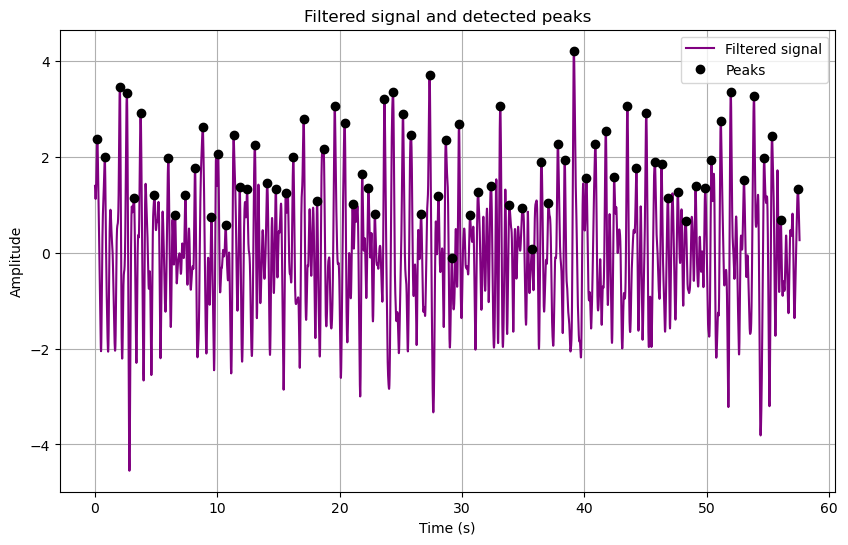

In [196]:

plt.figure(figsize=(10, 6))

# Filtered signal with detected peaks
plt.plot(cs_clean['Time'], filtered_signal, color='purple', label='Filtered signal')
plt.plot(peak_times, filtered_signal[peaks], 'o', color='black', label='Peaks')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filtered signal and detected peaks")
plt.legend()
plt.grid()



Text(0.5, 1.0, 'Histogram of instantaneous BPM')

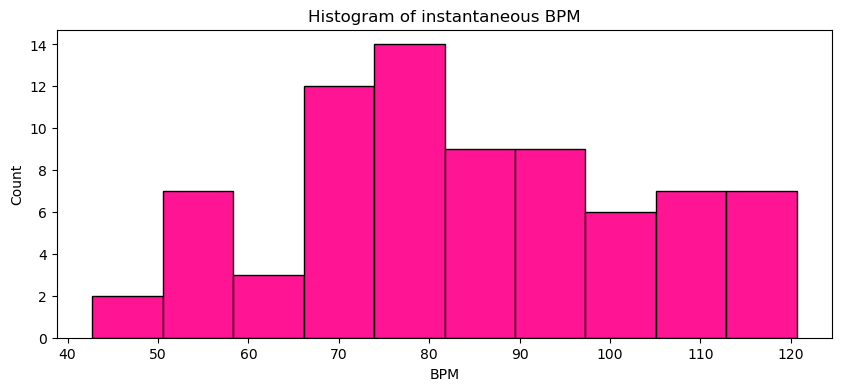

In [197]:
plt.figure(figsize=(10,4))
plt.hist(bpm_inst, bins=10, color='deeppink',edgecolor='black')
plt.xlabel("BPM")
plt.ylabel("Count")
plt.title("Histogram of instantaneous BPM")


In [198]:
print("Mean BPM:", np.mean(bpm_inst))
print("Std BPM:", np.std(bpm_inst))
print("Min BPM:", np.min(bpm_inst))
print("Max BPM:", np.max(bpm_inst))

Mean BPM: 84.1762020772742
Std BPM: 18.954460096295467
Min BPM: 42.724762726488464
Max BPM: 120.65789473684194


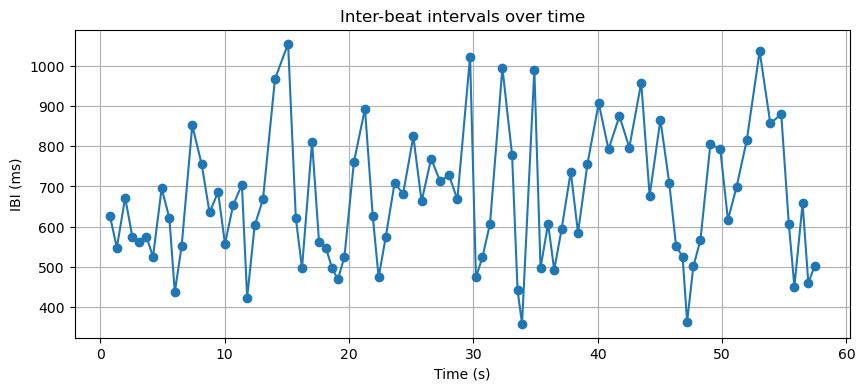

In [149]:
ibi_times = peak_times[1:]  # each IBI corresponds to interval ending at peak i+1

plt.figure(figsize=(10,4))
plt.plot(ibi_times, ibi_ms, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("IBI (ms)")
plt.title("Inter-beat intervals over time")
plt.grid()
plt.show()

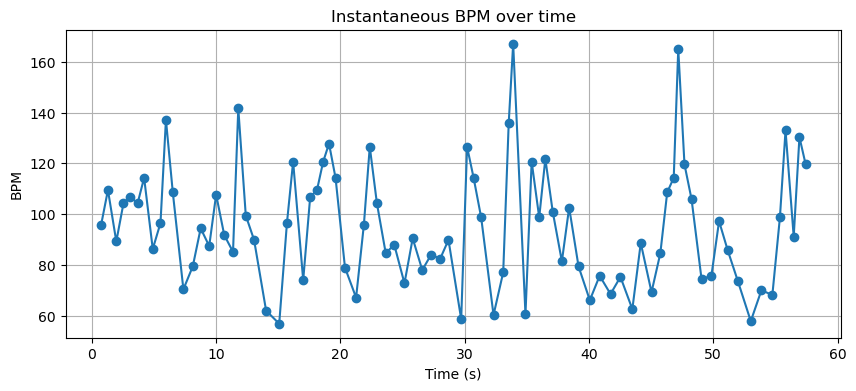

In [150]:
plt.figure(figsize=(10,4))
plt.plot(ibi_times, bpm_inst, marker='o')
plt.xlabel("Time (s)")
plt.ylabel("BPM")
plt.title("Instantaneous BPM over time")
plt.grid()
plt.show()

HRV measures the beat-to-beat variation in cardiac rhythm. It is important because it reflects how the autonomic nervous system regulates the heart. A healthy heart does not beat at perfectly constant intervals; instead, small fluctuations are expected and often indicate adaptive cardiovascular control. Low HRV can be associated with stress, fatigue, poor recovery, or certain cardiovascular conditions, while higher HRV is often related to better autonomic flexibility and physiological resilience.

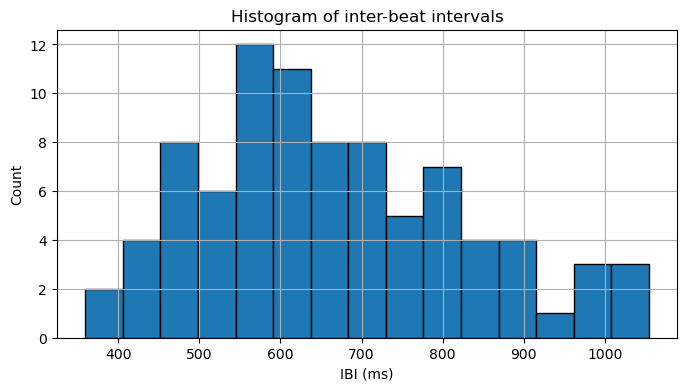

In [151]:
plt.figure(figsize=(8,4))
plt.hist(ibi_ms, bins=15, edgecolor='black')
plt.xlabel("IBI (ms)")
plt.ylabel("Count")
plt.title("Histogram of inter-beat intervals")
plt.grid()
plt.show()

In [ ]:
from scipy.signal import find_peaks

# 1. Detectar los picos en la señal filtrada
# 'distance' evita detectar picos muy juntos (ruido)
# 'height' asegura que el pico tenga una altura mínima
min_dist = samples_per_second #  asumiendo un max de 180 bpm
peaks, _ = find_peaks(filtered_signal, distance=min_dist, height=0)

# 2. Calcular los intervalos entre picos
# np.diff resta la posición del pico actual menos el anterior
interval = np.diff(peaks)
time_interval = interval / samples_per_second

# 3. Convertir cada intervalo a su equivalente en BPM
bpm = 60 * time_interval

c:\Users\andre\anaconda3\Lib\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


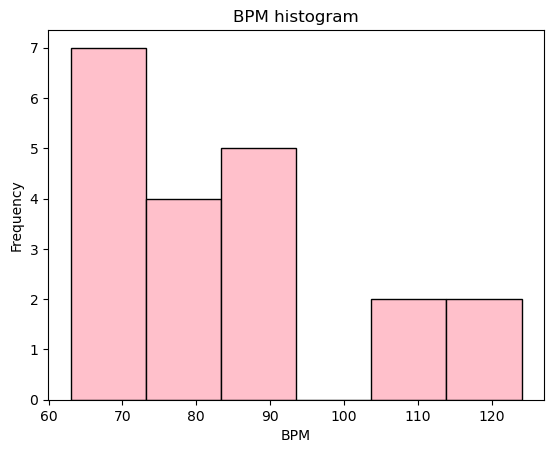

In [ ]:
plt.hist(bpm, bins='sturges', color='pink', edgecolor='black')

plt.title("BPM histogram")
plt.xlabel("BPM")
plt.ylabel("Frequency")
plt.show()

# Bibliography and final comments

* Haescher, M., Matthies, D. J., Trimpop, J., & Urban, B. (2015, June). A study on measuring heart-and respiration-rate via wrist-worn accelerometer-based seismocardiography (SCG) in comparison to commonly applied technologies. In Proceedings of the 2nd international Workshop on Sensor-based Activity Recognition and Interaction (pp. 1-6).

* Balali, P., Rabineau, J., Hossein, A., Tordeur, C., Debeir, O., & Van De Borne, P. (2022). Investigating cardiorespiratory interaction using ballistocardiography and seismocardiography—a narrative review. Sensors, 22(23), 9565.

* Belaish, E. (2022). Know your sensors: An introduction to inertial sensors. 221e. URL: https://www.221e.com/wp-content/uploads/2022/11/221e-Whitepaper-An-Introduction-to-Inertial-Sensors.pdf

* Zigliotto, W., & Belaish, E. (2022). 3 IMU sensor fusion troublemakers and how you can outsmart them. 221e. URL: https://www.221e.com/wp-content/uploads/2022/11/221e-Whitepaper-3-IMU-Sensor-Fusion-Troublemakers.pdf

* Inan, O. T., Migeotte, P. F., Park, K. S., Etemadi, M., Tavakolian, K., Casanella, R., ... & Di Rienzo, M. (2014). Ballistocardiography and seismocardiography: A review of recent advances. IEEE journal of biomedical and health informatics, 19(4), 1414-1427.